<a href="https://colab.research.google.com/github/Apoorv070/AI-Agent-Revison-Notebooks/blob/main/4_Intro_to_Langraphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELL 1 — Install packages
!pip install -qU langgraph langchain langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.8/169.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.7/112.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 4.0 MB/s eta 0:00:00


In [2]:
# CELL 2 — Read keys from Colab user data
from google.colab import userdata
import os

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")

## Intro to Langraph

In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

In [4]:
class HelloState(TypedDict):
  name: str
  reply: str


In [5]:
def say_hello(state: HelloState):
    return {
        "reply": f"Hello, {state['name']}!"
    }

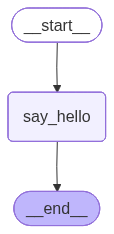

In [6]:
hello_builder = StateGraph(HelloState)
hello_builder.add_node('say_hello', say_hello)
hello_builder.add_edge(START, 'say_hello')
hello_builder.add_edge('say_hello', END)
graph = hello_builder.compile()
graph

In [7]:
graph.invoke({"name": "Sameer", "reply": ""})

{'name': 'Sameer', 'reply': 'Hello, Sameer!'}

In [8]:
  ### Tool calling with Langraph

In [9]:
# CELL 4 — Imports for the weather example

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI

from langgraph.graph import StateGraph, MessagesState, START
from langgraph.prebuilt import ToolNode, tools_condition

In [10]:
# CELL 5 — Very simple weather tool
# No validator, no error handling, no extra complexity

@tool
def get_weather(city: str) -> str:
    """Get weather for a city."""

    weather_data = {
        "Delhi": "Hot, 34C, humidity 48%",
        "Mumbai": "Humid, 31C, humidity 78%",
        "Bengaluru": "Pleasant, 27C, humidity 60%",
    }

    return weather_data.get(city, "Weather data not found")

In [11]:
# CELL 6 — LLM with tool binding

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

llm_with_tools = llm.bind_tools([get_weather])

In [12]:
### LLM node
# CELL 6 — LLM with tool binding

def llm_node(state: MessagesState):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

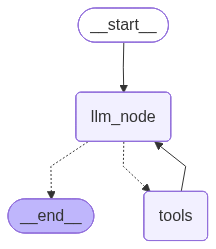

In [13]:
builder = StateGraph(MessagesState)
builder.add_node("llm_node", llm_node)
tool_node = ToolNode([get_weather])
builder.add_node("tools", tool_node)
builder.add_conditional_edges("llm_node", tools_condition)
builder.add_edge("tools", "llm_node")
builder.add_edge(START, "llm_node")
# builder.conditional_edges("llm_node", END)
graph = builder.compile()
graph

In [14]:
query = input("Ask me anything: ")
result = graph.invoke({"messages": [HumanMessage(query)]})

print("FULL FLOW")
for i, msg in enumerate(result['messages'], start = 1):
  print(f"Message{i}: {type(msg).__name__}")
  print(msg)
  print()

Ask me anything: what is weather in delhi
FULL FLOW
Message1: HumanMessage
content='what is weather in delhi' additional_kwargs={} response_metadata={} id='6b246735-6078-42fd-b561-a3edb79f76e9'

Message2: AIMessage
content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 49, 'total_tokens': 63, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_ff0b09a830', 'id': 'chatcmpl-DU3071frRZ5L6dmTeGRI9jCSUPt6j', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019d850d-797c-7b52-8535-3f70ffbecb06-0' tool_calls=[{'name': 'get_weather', 'args': {'city': 'Delhi'}, 'id': 'call_evU0VSY97E825NGunziSo26H', 'type': 'tool_call'}] invalid_tool_calls=[] us

In [15]:
result['messages']

[HumanMessage(content='what is weather in delhi', additional_kwargs={}, response_metadata={}, id='6b246735-6078-42fd-b561-a3edb79f76e9'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 49, 'total_tokens': 63, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_ff0b09a830', 'id': 'chatcmpl-DU3071frRZ5L6dmTeGRI9jCSUPt6j', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d850d-797c-7b52-8535-3f70ffbecb06-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Delhi'}, 'id': 'call_evU0VSY97E825NGunziSo26H', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 49, 'output_tokens': 14, 'tota

### Variations of STATE

In [16]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

In [17]:
class WeatherState(TypedDict):
    messages: Annotated[list, add_messages]

In [18]:
def llm_node(state: WeatherState):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

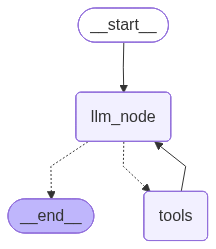

In [19]:
builder = StateGraph(WeatherState)
builder.add_node("llm_node", llm_node)
tool_node = ToolNode([get_weather])
builder.add_node("tools", tool_node)
builder.add_conditional_edges("llm_node", tools_condition)
builder.add_edge("tools", "llm_node")
builder.add_edge(START, "llm_node")
# builder.conditional_edges("llm_node", END)
graph = builder.compile()
graph

In [20]:
query = input("Ask me anything: ")
result = graph.invoke({"messages": [HumanMessage(query)]})

print("FULL FLOW")
for i, msg in enumerate(result['messages'], start = 1):
  print(f"Message{i}: {type(msg).__name__}")
  print(msg)
  print()

Ask me anything: what is weather in punjab
FULL FLOW
Message1: HumanMessage
content='what is weather in punjab' additional_kwargs={} response_metadata={} id='e1034f6e-776a-4c7e-96e4-a4d9fc0330d4'

Message2: AIMessage
content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 49, 'total_tokens': 63, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_905fb9dc0d', 'id': 'chatcmpl-DU36Qu3Cj05QcJjTCT1uogNx0OXdX', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019d8513-735f-74e1-b350-7f67aa2fa37f-0' tool_calls=[{'name': 'get_weather', 'args': {'city': 'Punjab'}, 'id': 'call_3tINxjG2aPWRIZpTF23K1YK1', 'type': 'tool_call'}] invalid_tool_calls=[]

#### TOOL CALLING VARIATION?

In [21]:
from typing import Literal
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

In [23]:
class MyState(TypedDict):
    number: int
    # result : str // if we use this then the state data will be over ridden in every state , hence we use reducers like result here
    result: Annotated[list, add_messages]

In [24]:
def check_number(state: MyState):
    return {
        "result": [f"Received number = {state['number']}"],
        "message": "Hello"
    }

In [25]:
def even_node(state: MyState):
    return {
        "result": [f"{state['number']} is even, so I came to even_node"]
    }

In [26]:
def route_function(state: MyState) -> Literal["even_node", END]:
    if state["number"] % 2 == 0:
        return "even_node"
    return END

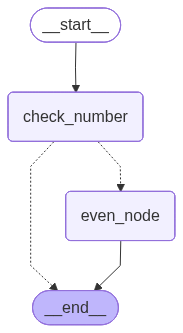

In [27]:
builder = StateGraph(MyState)
builder.add_node("check_number", check_number)
builder.add_node("even_node", even_node)
builder.add_edge(START, "check_number")
builder.add_conditional_edges("check_number", route_function)
builder.add_edge("even_node", END)
graph = builder.compile()
graph

In [28]:
result = graph.invoke({'number': 4, "result": []})

In [29]:
result

{'number': 4,
 'result': [HumanMessage(content='Received number = 4', additional_kwargs={}, response_metadata={}, id='d55d3581-4639-4705-8f0c-5ecbc8f10138'),
  HumanMessage(content='4 is even, so I came to even_node', additional_kwargs={}, response_metadata={}, id='57935402-f187-43d5-88c4-9a9acb1f3025')]}

### Home Work

In [30]:
from typing import Annotated, Literal
from typing_extensions import TypedDict

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

In [31]:
class MyState(TypedDict):
    messages: Annotated[list, add_messages]

In [32]:

@tool
def get_weather(city: str) -> str:
    """Get weather for a city."""
    weather_data = {
        "Delhi": "Hot, 34C",
        "Mumbai": "Humid, 31C",
        "Bengaluru": "Pleasant, 27C",
    }
    return weather_data.get(city, "Weather data not found")


@tool
def add_numbers(a: int, b: int) -> str:
    """Add two numbers."""
    return f"Sum is {a + b}"

In [33]:
# CELL 4 — LLM with both tools

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

llm_with_tools = llm.bind_tools([get_weather, add_numbers])

In [34]:
def llm_node(state: MyState):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

In [35]:
# CELL 6 — Custom routing function
# This decides WHICH tool node to go to

def route_tools(state: MyState) -> Literal["weather_tools", "math_tools", END]:
    last_message = state["messages"][-1]

    if not last_message.tool_calls:
        return END

    tool_name = last_message.tool_calls[0]["name"]

    if tool_name == "get_weather":
        return "weather_tools"

    if tool_name == "add_numbers":
        return "math_tools"

    return END

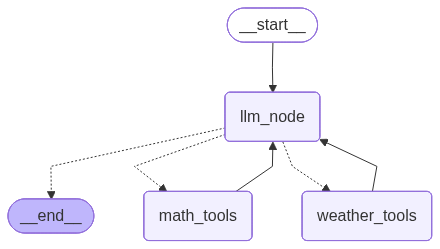

In [37]:
### BUILD THE GRAPH AND RUN IT!!
builder = StateGraph(MyState)
#llm node
builder.add_node("llm_node", llm_node)
tool_node_weather = ToolNode([get_weather])
builder.add_node("weather_tools", tool_node_weather)
tool_node_math = ToolNode([add_numbers])
builder.add_node("math_tools", tool_node_math)


##Edges
builder.add_edge(START, "llm_node")
builder.add_conditional_edges("llm_node", route_tools)
builder.add_edge("weather_tools", "llm_node")
builder.add_edge("math_tools", "llm_node")
#builder.add_edge("leem_node",END) # Removed this line as it was causing the error and is redundant
#builder.add_conditional_edges("llm_node", tools_condition)
graph = builder.compile()
graph

In [39]:
result = graph.invoke({"messages": [HumanMessage("what is weather in delhi")]})

In [40]:
result

{'messages': [HumanMessage(content='what is weather in delhi', additional_kwargs={}, response_metadata={}, id='660cb7f6-dd06-4046-8856-c7f77d0aafe8'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 71, 'total_tokens': 85, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_34e6d0d598', 'id': 'chatcmpl-DU3RLbZFcKnU9hJZ18VBubDj8LNVt', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d8527-3bf4-73d0-82f1-efd0591d81bc-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Delhi'}, 'id': 'call_VQnxoL6zN0wOLTKfrVySLWzN', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 71, 'output_toke

In [41]:
print("FULL FLOW")
for i, msg in enumerate(result['messages'], start = 1):
  print(f"Message{i}: {type(msg).__name__}")
  print(msg)
  print()

FULL FLOW
Message1: HumanMessage
content='what is weather in delhi' additional_kwargs={} response_metadata={} id='660cb7f6-dd06-4046-8856-c7f77d0aafe8'

Message2: AIMessage
content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 71, 'total_tokens': 85, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_34e6d0d598', 'id': 'chatcmpl-DU3RLbZFcKnU9hJZ18VBubDj8LNVt', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019d8527-3bf4-73d0-82f1-efd0591d81bc-0' tool_calls=[{'name': 'get_weather', 'args': {'city': 'Delhi'}, 'id': 'call_VQnxoL6zN0wOLTKfrVySLWzN', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 71, 'output_